# Polynomials over subspaces

### Introduction <a class='anchor' id='intro'></a>

Active subspaces and the related polynomial ridge approximation represent a powerful set of ideas for output-based data-driven dimension reduction. In a nutshell, the idea is to identify a subspace along which the data (or data-generating function) can be well approximated. While this has some similarity (at least notionally) to principal component analysis (PCA), it is very different. In PCA, the input-output relationship is only delineated by the distribution of the inputs. However, in active subspaces, the input-output relationship is explicitly delienated by the gradient (or an approximation thereof) of the output with respect to the inputs.

In [1]:
import plotly.express as px
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import equadratures as eq

In [2]:
data = eq.datasets.load_eq_dataset('3Dfan_blades',verbose=False) # Download the data
X = data['X_a']
y = data['y1_a']

We now feed this data to `equadratures`' Subspace class. Underneath the hood, the code fits a polynomial model to the data (via least squares) and then uses the gradients to compute the active subspace via the approximation

$$C = \int \nabla_{x}p(x) \nabla_{x}p^{T}(x) \rho(x) dx$$

whereupon eigenvalues $\Lambda$ and eigenvectors $W$ can be computed via an eigendecomposition

$$C = W \Lambda W^{T}$$

In [3]:
# Active subspace computation
sub = eq.Subspaces(sample_points=X, sample_outputs=y, \
                   method='active-subspaces')
W = sub.get_subspace()

We define the active subspace by the dominant eigenvectors.

In [4]:
# Plotting 

df = pd.DataFrame({'Eigenvalues (log)': np.log10(np.abs(sub.get_eigenvalues())) , 
                   'Parameter #': np.arange(X.shape[1])})
df2 = pd.DataFrame({'Active-1': X @ W[:,0], 
                    'Active-2': X @ W[:,1], 
                    'Efficiency': y})

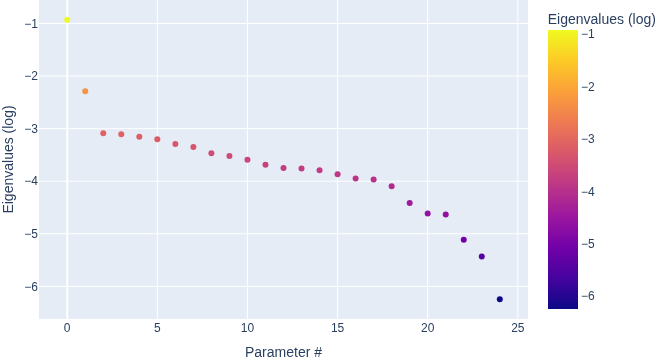

In [5]:
fig = px.scatter(df, x="Parameter #", y="Eigenvalues (log)", color="Eigenvalues (log)")
fig.update_layout(margin=dict(l=0, r=0, t=0, b=0))
fig.show()

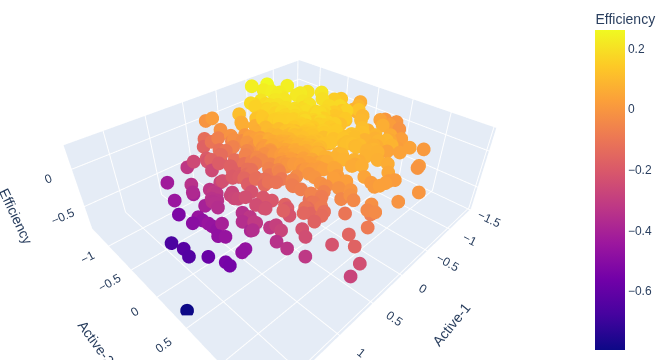

In [6]:
fig = px.scatter_3d(df2, x='Active-1', y='Active-2', z='Efficiency',
                    color='Efficiency')
fig.update_layout(margin=dict(l=0, r=0, t=0, b=0))
fig.show()

We can re-visit the above using the variable projection approach. To see it in practice, consider the following code

In [7]:
my_dr = eq.Subspaces(method='variable-projection', sample_points=X, sample_outputs=y, subspace_dimension=2)
W2 = my_dr.get_subspace()

In [8]:
# Plotting 
df3 = pd.DataFrame({'Direction-1': X @ W2[:,0], 
                    'Direction-2': X @ W2[:,1], 
                    'Efficiency': y})

In [9]:
fig = px.scatter_3d(df3, x='Direction-1', y='Direction-2', z='Efficiency',
                    color='Efficiency')
fig.update_layout(margin=dict(l=0, r=0, t=0, b=0))
fig.show()